# Unemployment Analysis

<img src='https://i0.wp.com/indiadatamap.com/wp-content/uploads/2025/07/indian-states-by-unemployment-rates-1.png?resize=1536%2C1536&ssl=1'>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

import warnings
warnings.filterwarnings('ignore')

# 3 Boyutlu Veri Görselleştirme Kütüphaneleri
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/amankharwal/Website-data/master/unemployment.csv")

In [3]:
#EDA

In [4]:
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


In [5]:
df.tail()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
262,West Bengal,30-06-2020,M,7.29,30726310,40.39,East,22.9868,87.855
263,West Bengal,31-07-2020,M,6.83,35372506,46.17,East,22.9868,87.855
264,West Bengal,31-08-2020,M,14.87,33298644,47.48,East,22.9868,87.855
265,West Bengal,30-09-2020,M,9.35,35707239,47.73,East,22.9868,87.855
266,West Bengal,31-10-2020,M,9.98,33962549,45.63,East,22.9868,87.855


In [ ]:
df.info()

In [8]:
df.isnull().sum()

Region                                      0
Date                                        0
 Frequency                                  0
 Estimated Unemployment Rate (%)            0
 Estimated Employed                         0
 Estimated Labour Participation Rate (%)    0
Region.1                                    0
longitude                                   0
latitude                                    0
dtype: int64

In [9]:
df.Region.value_counts()

Region
Andhra Pradesh      10
Assam               10
Bihar               10
Chhattisgarh        10
Delhi               10
Goa                 10
Gujarat             10
Haryana             10
Himachal Pradesh    10
Jharkhand           10
Karnataka           10
Rajasthan           10
Kerala              10
Madhya Pradesh      10
Maharashtra         10
Meghalaya           10
Odisha              10
Puducherry          10
Punjab              10
Uttarakhand         10
Tamil Nadu          10
Telangana           10
Tripura             10
West Bengal         10
Uttar Pradesh       10
Jammu & Kashmir      9
Sikkim               8
Name: count, dtype: int64

In [10]:
#Tüm sütun isimlerindeki baş/son boşlukları temizlemek için
df.columns = df.columns.str.strip()

In [11]:
df['Date'] = pd.to_datetime(df['Date'].str.strip(), format='%d-%m-%Y', errors='raise')

In [12]:
df.Date.head()

0   2020-01-31
1   2020-02-29
2   2020-03-31
3   2020-04-30
4   2020-05-31
Name: Date, dtype: datetime64[ns]

In [13]:
# Stils
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

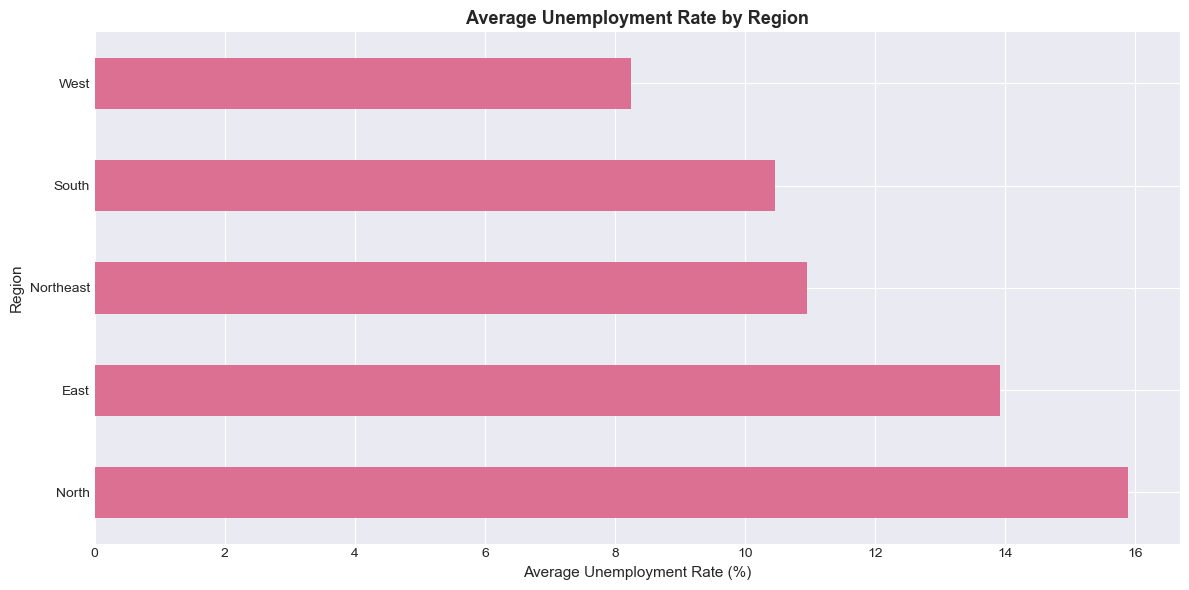

In [14]:
# Average Unemployment Rate by Region / Bölge Bazında İşsizlik Oranı
plt.figure(figsize=(12, 6))
df.groupby('Region.1')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False).plot(kind='barh', color='#DB7093')
plt.xlabel('Average Unemployment Rate (%)', fontsize=11)
plt.ylabel('Region', fontsize=11)
plt.title('Average Unemployment Rate by Region', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Ortalama işsizlik oranları bölgesel olarak değerlendirildiğinde ülkenin diğer bölgelerine kıyasla kuzeyinde daha fazla işsizlik oranlarının olduğu, güney ve batı bölgelerinde ise görece daha az bir orana sahip olduğu görülmektedir. 

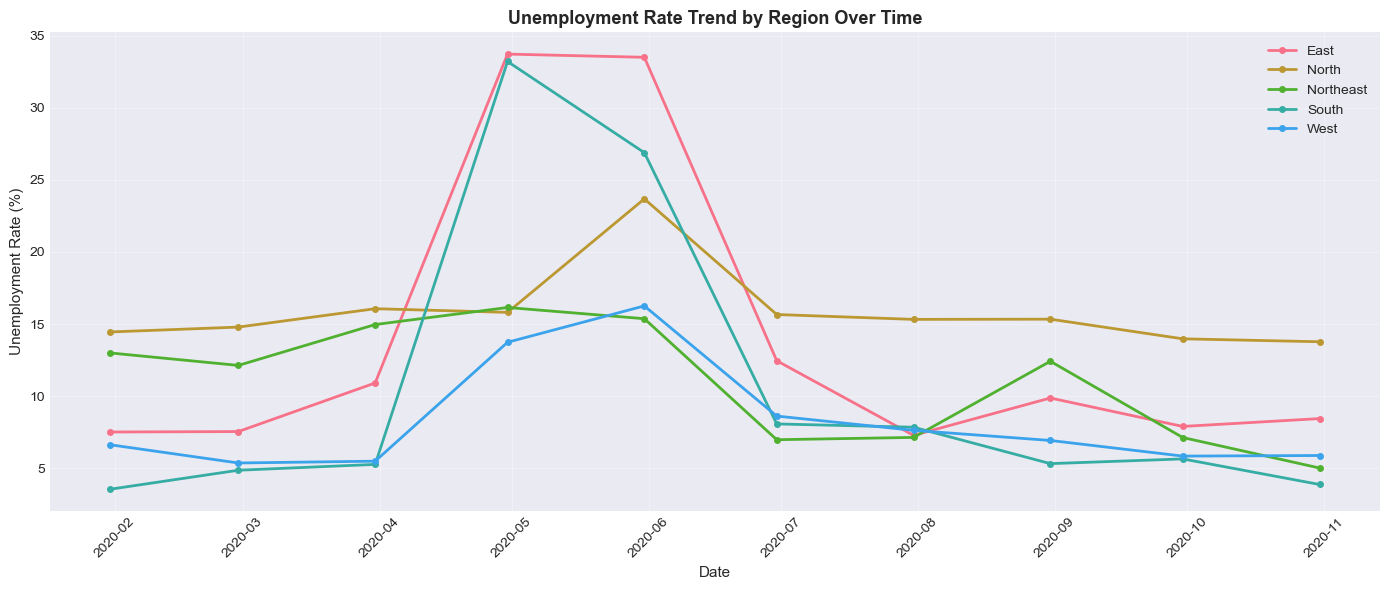

In [15]:
# Unemployment Rate Trend by Region
# pivot: index = Date, columns = Region.1, values = mean of rate
pt = df.pivot_table(index='Date', columns='Region.1', values='Estimated Unemployment Rate (%)', aggfunc='mean')

plt.figure(figsize=(14, 6))
plt.plot(pt.index, pt.values, marker='o', linewidth=2, markersize=4)   # tüm sütunlar tek çağrıda çizilir
plt.xlabel('Date', fontsize=11)
plt.ylabel('Unemployment Rate (%)', fontsize=11)
plt.title('Unemployment Rate Trend by Region Over Time', fontsize=13, fontweight='bold')
plt.legend(pt.columns, loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#NOT:pivot_table, pandas'ta veriyi yeniden şekillendirmek (reshape) ve özetlemek için kullanılan güçlü bir yöntemdir.
#Her farklı Date bir satır olur.
#Her farklı Region.1 bir sütun olur.
#Hücreler, o tarihte o bölgeye karşılık gelen "Estimated Unemployment Rate (%)" değerlerinin ortalamasını (mean) içerir.
#Eğer bir (Date, Region.1) eşleşmesi için birden çok satır varsa aggfunc ile belirtilen özet (ör. ortalama) alınır.

Aylık olarak işsizlik oranları incelendiğinde tüm bölgeler için Nisan-Temmuz ayların arasında işsizlik oranlarının arttığı görülmektedir. İlgili dataseti 2020 yılına ait olduğundan bu dönemdeki Nisan–Temmuz arasındaki işsizlik artışı büyük ölçüde COVID‑19 pandemisi ve 24 Mart 2020’de başlatılan ülke çapı sınırlandırmalar nedeniyle oldu. Kilitlenmeler sanayi, inşaat, hizmet ve günlük-gündelik işleri durdurdu, iç göç ve talep daralması iş kayıplarını hızlandırdı. Sonuç olarak kısa vadeli işsizliğin tüm bölgelerde belirgin şekilde yükselmesi beklenen bir yaşandı.        
Aşağıdaki haritada zamana bağlı olarak işsizlik oranları ve istihdam edilen insan sayısı mekansal olarak gösterilmektedir.

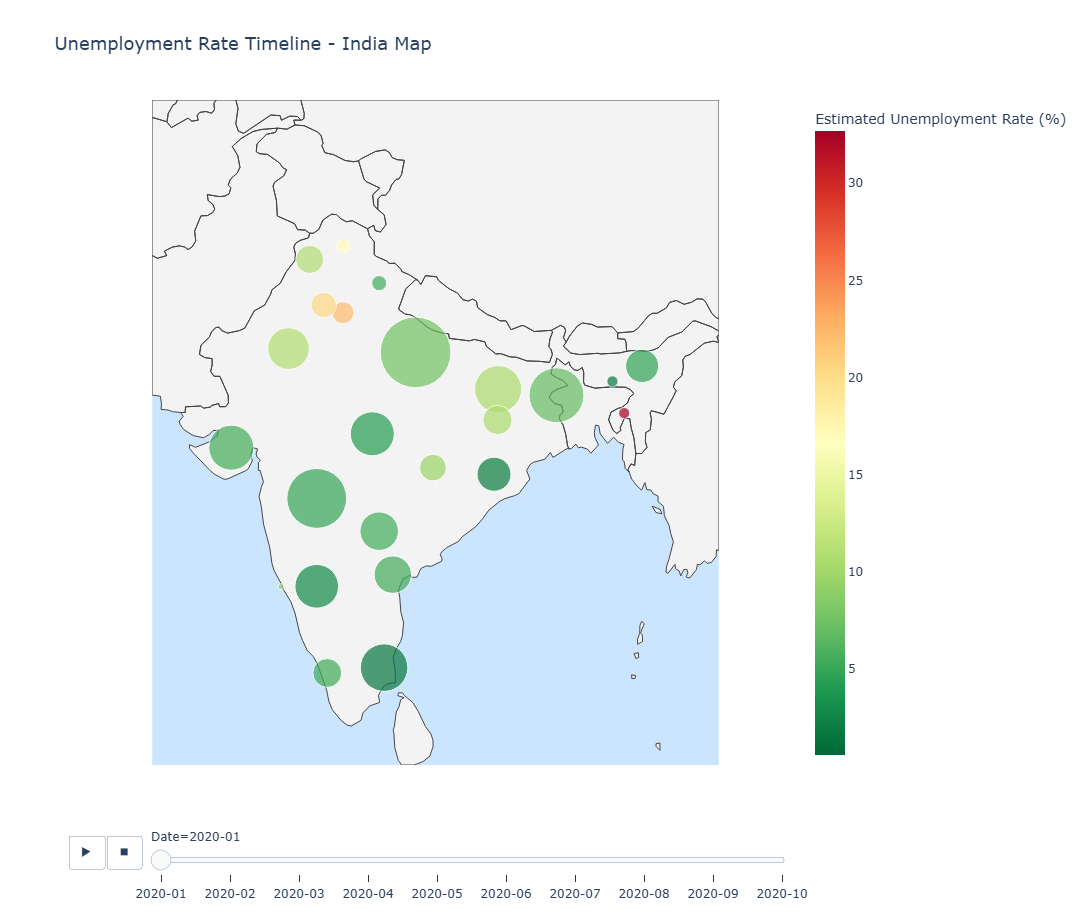

In [25]:
# Unemployment Rate Trend by Region / ANIMATED CHOROPLETH MAP 
# India bölgelerinin doğru koordinatları
region_coords = {
    'Andhra Pradesh': {'lat': 15.9129, 'lon': 79.7400},
    'Assam': {'lat': 26.2006, 'lon': 92.9376},
    'Bihar': {'lat': 25.0961, 'lon': 85.3131},
    'Chhattisgarh': {'lat': 21.2787, 'lon': 81.8661},
    'Delhi': {'lat': 28.7041, 'lon': 77.1025},
    'Goa': {'lat': 15.2993, 'lon': 73.8243},
    'Gujarat': {'lat': 22.2587, 'lon': 71.1924},
    'Haryana': {'lat': 29.0588, 'lon': 76.0856},
    'Himachal Pradesh': {'lat': 31.7433, 'lon': 77.1205},
    'Jharkhand': {'lat': 23.6102, 'lon': 85.2799},
    'Karnataka': {'lat': 15.3173, 'lon': 75.7139},
    'Kerala': {'lat': 10.8505, 'lon': 76.2711},
    'Madhya Pradesh': {'lat': 22.9375, 'lon': 78.6553},
    'Maharashtra': {'lat': 19.7515, 'lon': 75.7139},
    'Manipur': {'lat': 24.6637, 'lon': 93.9063},
    'Meghalaya': {'lat': 25.4670, 'lon': 91.3662},
    'Mizoram': {'lat': 23.1815, 'lon': 92.9789},
    'Nagaland': {'lat': 26.1584, 'lon': 94.5624},
    'Odisha': {'lat': 20.9517, 'lon': 85.0985},
    'Punjab': {'lat': 31.1471, 'lon': 75.3412},
    'Rajasthan': {'lat': 27.0238, 'lon': 74.2179},
    'Sikkim': {'lat': 27.5330, 'lon': 88.5122},
    'Tamil Nadu': {'lat': 11.1271, 'lon': 79.2787},
    'Telangana': {'lat': 18.1124, 'lon': 79.0193},
    'Tripura': {'lat': 23.9408, 'lon': 91.9882},
    'Uttar Pradesh': {'lat': 26.8467, 'lon': 80.9462},
    'Uttarakhand': {'lat': 30.0668, 'lon': 79.0193},
    'West Bengal': {'lat': 24.8045, 'lon': 88.4038}
}

# Veri hazırlama
df_monthly = df.groupby([df['Date'].dt.to_period('M'), 'Region']).agg({
    'Estimated Unemployment Rate (%)': 'mean',
    'Estimated Employed': 'mean'
}).reset_index()

# Koordinatları ekle
df_monthly['latitude'] = df_monthly['Region'].map(lambda x: region_coords.get(x, {}).get('lat'))
df_monthly['longitude'] = df_monthly['Region'].map(lambda x: region_coords.get(x, {}).get('lon'))
df_monthly['Date'] = df_monthly['Date'].astype(str)

fig4 = px.scatter_geo(df_monthly,
                     lat='latitude',
                     lon='longitude',
                     animation_frame='Date',
                     size='Estimated Employed',
                     color='Estimated Unemployment Rate (%)',
                     hover_name='Region',
                     color_continuous_scale='RdYlGn_r',
                     title='Unemployment Rate Timeline - India Map',
                     scope='asia',
                     size_max=50)

# Harita görünümünü iyileştir ve büyüt
fig4.update_layout(
    height=900,
    width=1400,
    geo=dict(
        center=dict(lat=23, lon=82),
        projection_type='mercator',
        showland=True,
        landcolor='rgb(243, 243, 243)',
        showocean=True,
        oceancolor='rgb(204, 229, 255)',
        showlakes=True,
        lakecolor='rgb(204, 229, 255)',
        coastlinecolor='rgb(150, 150, 150)',
        lataxis=dict(range=[6, 38]),
        lonaxis=dict(range=[68, 98])
    ),
    font=dict(size=12),
    title=dict(font=dict(size=18))
)

fig4.show()

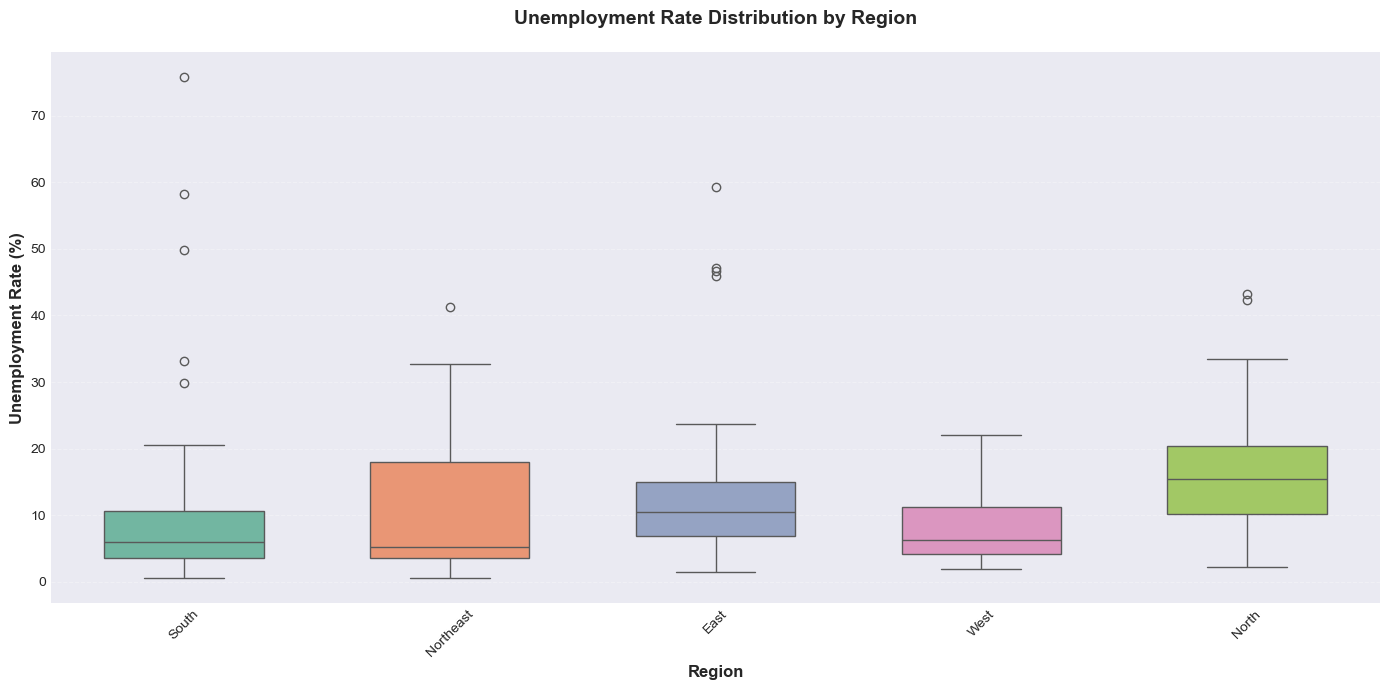

In [19]:
# Unemployment Rate Distribution by Region with Outliers
plt.figure(figsize=(14, 7))
sns.boxplot(data=df, x='Region.1', y='Estimated Unemployment Rate (%)', palette='Set2', width=0.6)
plt.xlabel('Region', fontsize=12, fontweight='bold')
plt.ylabel('Unemployment Rate (%)', fontsize=12, fontweight='bold')
plt.title('Unemployment Rate Distribution by Region', fontsize=14, fontweight='bold', pad=20)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.xticks(rotation=45, fontsize=10)
plt.tight_layout()
plt.show()

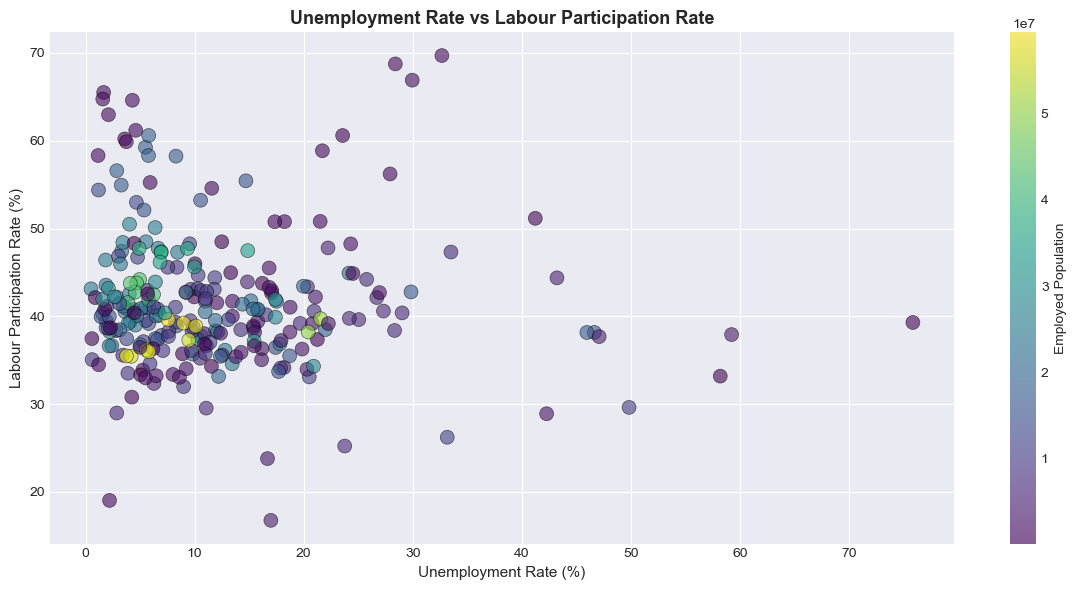

In [16]:
# Unemployment Rate vs Labour Participation Rate
plt.figure(figsize=(12, 6))
scatter = plt.scatter(df['Estimated Unemployment Rate (%)'], 
                     df['Estimated Labour Participation Rate (%)'],
                     c=df['Estimated Employed'],
                     s=100, alpha=0.6, cmap='viridis', edgecolors='black', linewidth=0.5)
plt.xlabel('Unemployment Rate (%)', fontsize=11)
plt.ylabel('Labour Participation Rate (%)', fontsize=11)
plt.title('Unemployment Rate vs Labour Participation Rate', fontsize=13, fontweight='bold')
cbar = plt.colorbar(scatter)
cbar.set_label('Employed Population', fontsize=10)
plt.tight_layout()
plt.show()

İşsizlik oranının %70 seviyesine çıkabildiği noktalar varken, işgücüne katılım oranı ise çoğunluk 30–50 civarında kümelenmiş durumdadır. Yani bölgelerin çoğu nispeten benzer işgücüne katılım seviyelerine sahipken işsizlikte büyük farklar görünmektedir.

İstihdam edilen nüfusa bakıldığında, büyük nüfuslu bölgelerin de genelde düşük–orta işsizlik aralığında kümelendiği görülmektedir.

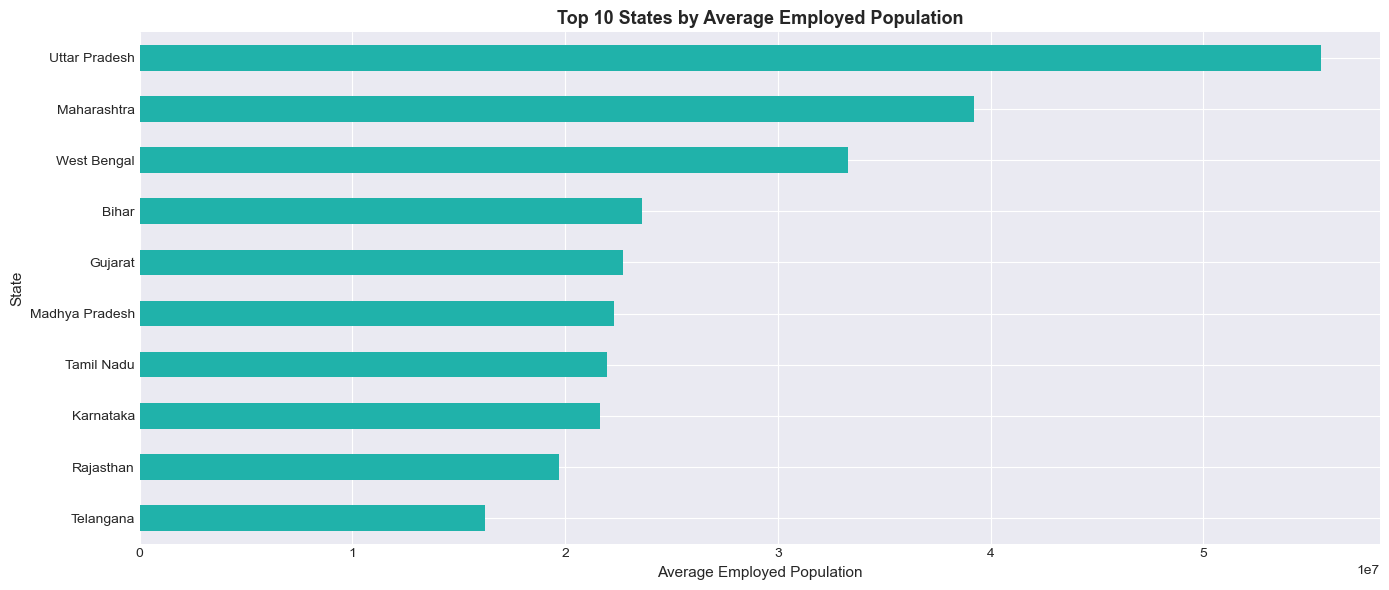

In [18]:
# Average Employed Population by Region/ Eyaletlere Göre Ortalama İstihdam Edilen Nüfus İlk 10 Bölge
plt.figure(figsize=(14, 6))
df.groupby('Region')['Estimated Employed'].mean().nlargest(10).sort_values(ascending=True).plot(kind='barh', color='#20B2AA')
plt.xlabel('Average Employed Population', fontsize=11)
plt.ylabel('State', fontsize=11)
plt.title('Top 10 States by Average Employed Population', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Eyaletlere göre en çok istihdam edilen kişi sayısı sırasıyla Uttar Pradesh, Maharashtra ve West Bengal eyalatleridir

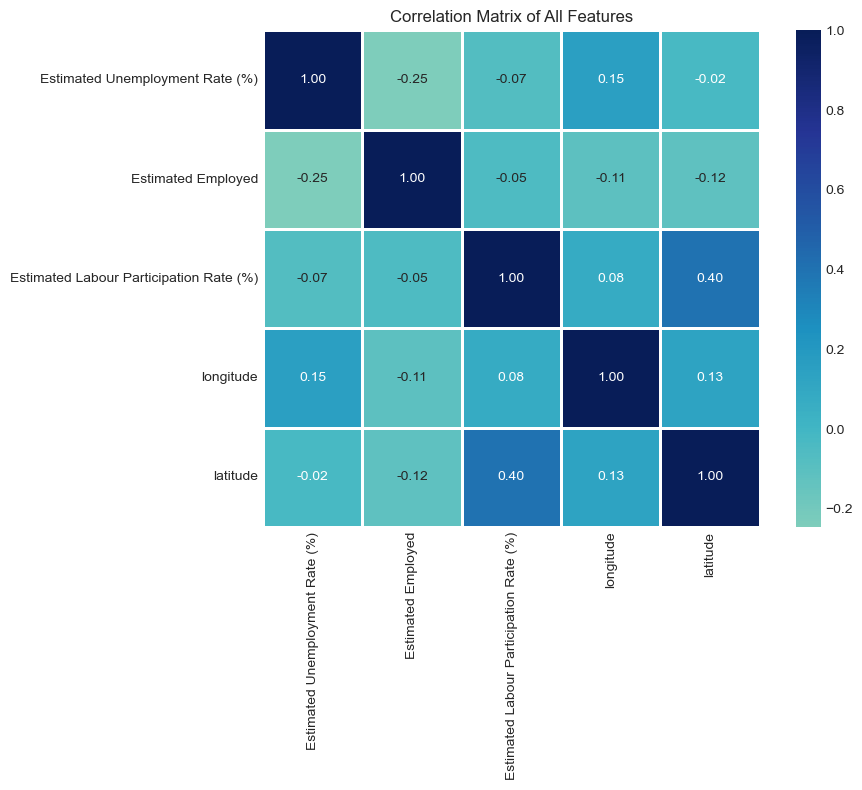

In [20]:
# Correlation Heatmap
num = df.select_dtypes(include='number')
correlation_matrix = num.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='YlGnBu', center=0,fmt='.2f', square=True, linewidths=1)
plt.title('Correlation Matrix of All Features')
plt.tight_layout()
plt.show()

İşsizlik oranı ile istihdam edilen kişi sayısı arasında negatif yönlü bir ilişki olduğu görülmektedir. Bu da işsizliğin çoğunlukla işgücü kaybı ile ilişkili olabilceğine işaret etmektedir (-0.25).

İşgücü katılımının coğrafi olarak anlamlı bir ilişki kurmaktadır. Bu gösterge bazı bölgelerin sosyo-ekonomik dinamiklerinin daha iyi olduğu anlamına gelmektedir (0.40).

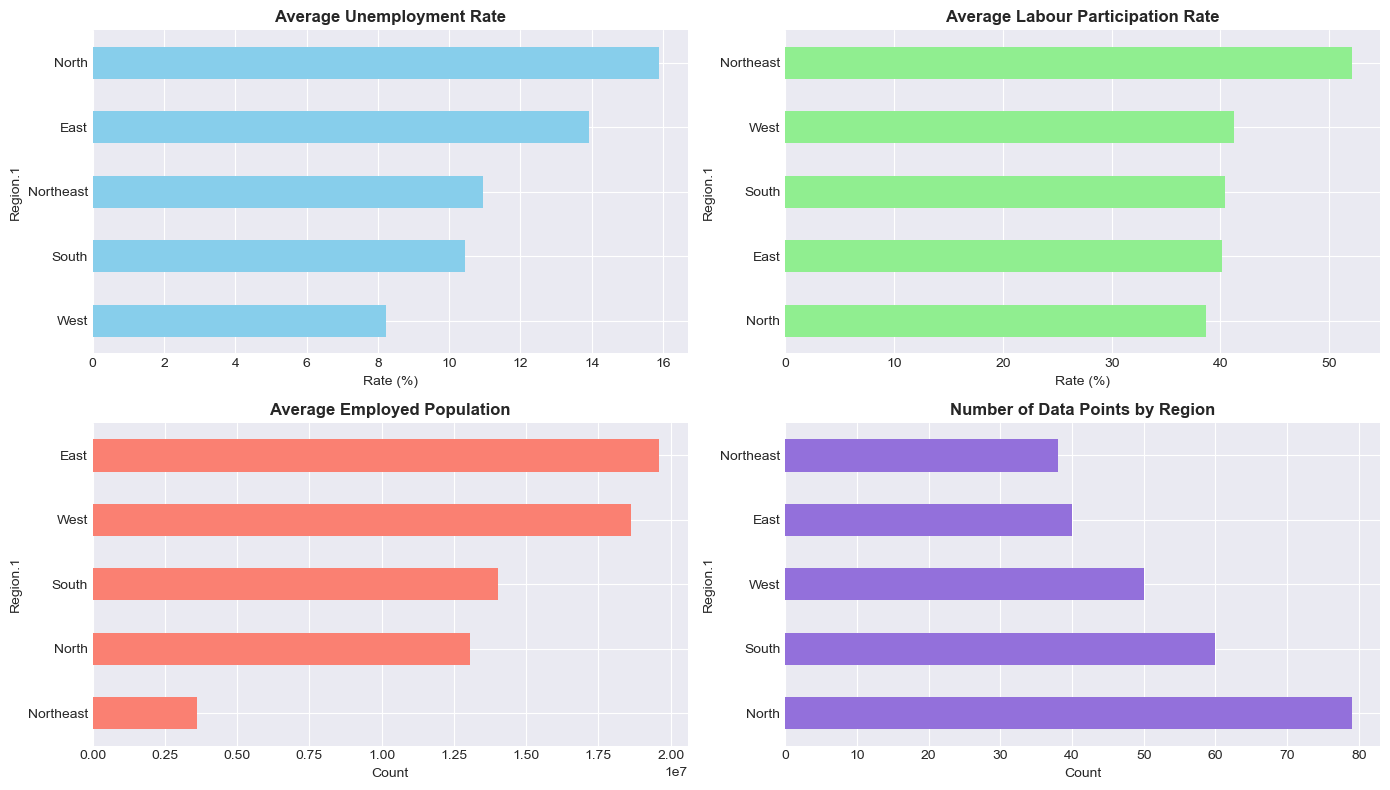

In [21]:
# Regional Comparison Dashboard
plt.figure(figsize=(14, 8))

plt.subplot(2, 2, 1)
df.groupby('Region.1')['Estimated Unemployment Rate (%)'].mean().sort_values().plot(kind='barh', color='skyblue')
plt.title('Average Unemployment Rate', fontweight='bold')
plt.xlabel('Rate (%)')

plt.subplot(2, 2, 2)
df.groupby('Region.1')['Estimated Labour Participation Rate (%)'].mean().sort_values().plot(kind='barh', color='lightgreen')
plt.title('Average Labour Participation Rate', fontweight='bold')
plt.xlabel('Rate (%)')

plt.subplot(2, 2, 3)
df.groupby('Region.1')['Estimated Employed'].mean().sort_values().plot(kind='barh', color='salmon')
plt.title('Average Employed Population', fontweight='bold')
plt.xlabel('Count')

plt.subplot(2, 2, 4)
df['Region.1'].value_counts().plot(kind='barh', color='mediumpurple')
plt.title('Number of Data Points by Region', fontweight='bold')
plt.xlabel('Count')

plt.tight_layout()
plt.show()

Grafikler 
En Yüksek İşsizlik; Kuzey bölgesi yaklaşık %16 ile en yüksek işsizlik oranına sahip. Onu %14 civarıyla Doğu takip ediyor.En Düşük İşsizlik Batı bölgesi yaklaşık %8 ile istihdamın en sağlıklı olduğu bölge olarak öne çıkıyor.

İş Gücüne Katılıma bakıldığında, Kuzeydoğu (Northeast) bölgesi %50'nin üzerindeki katılım oranıyla lider. İlginç olan, Kuzey (North) bölgesinin iş gücüne katılımda en son sırada yer alması; yani bu bölgede hem çalışan az hem de iş arayanların oranı yüksek.

İstihdam Edilen Nüfus olarak lider Bölgeler; Doğu ve Batı bölgeleri, 17.5 ile 20 milyon arasında değişen rakamlarla en yüksek çalışan nüfusa sahip yerler. En Düşük İstihdam ise Kuzeydoğu (Northeast) bölgesi, iş gücüne katılım oranı yüksek olsa da toplam çalışan sayısı bakımından (yaklaşık 4 milyon) diğer bölgelerin oldukça gerisinde kalmış durumdadır.

Genel olarak değerlendirildiğinde ekonomik olarak en hareketli bölgelerin Doğu ve Batı olduğunu gösteriyor. Kuzey bölgesi, yüksek işsizlik ve düşük iş gücüne katılım ile ekonomik açıdan en çok zorlanan bölge profili çiziyor.

In [26]:
#Son tarihteki veriyi alalım
df_latest= df[df['Date'] == df['Date'].max()]

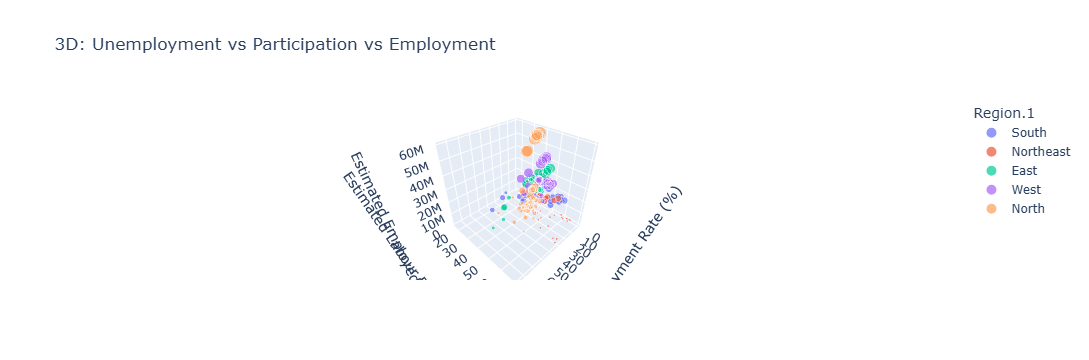

In [27]:
# SCATTER 3D / Unemployment vs Participation vs Employment
fig = px.scatter_3d(df,
                    x='Estimated Unemployment Rate (%)',
                    y='Estimated Labour Participation Rate (%)',
                    z='Estimated Employed',
                    color='Region.1',
                    size='Estimated Employed',
                    hover_name='Region',
                    title='3D: Unemployment vs Participation vs Employment')
fig.show()

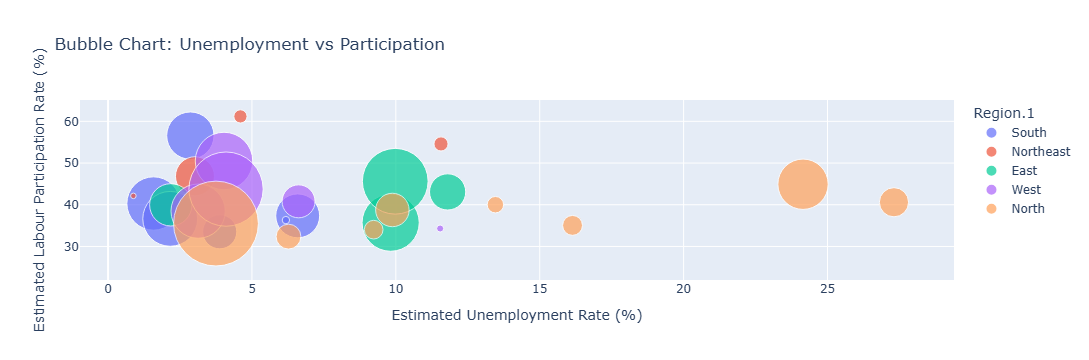

In [28]:
# Bubble Chart/ Unemployment vs Participation vs Employment
fig = px.scatter(df_latest,
                 x='Estimated Unemployment Rate (%)',
                 y='Estimated Labour Participation Rate (%)',
                 size='Estimated Employed',
                 color='Region.1',
                 hover_name='Region',
                 title='Unemployment vs Participation vs Employment',
                 size_max=60)
fig.show()

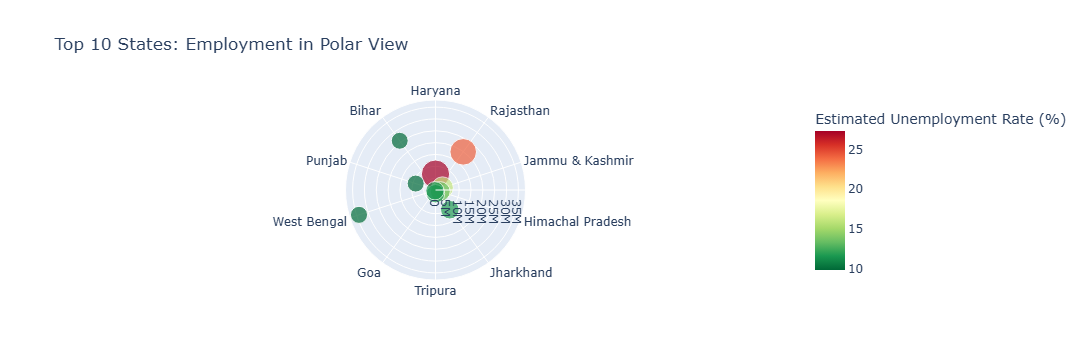

In [29]:
# RADIAL SCATTER/ 'Top 10 States: Employment in Polar View
df_radial = df_latest.sort_values('Estimated Unemployment Rate (%)', ascending=False).head(10)
fig12 = px.scatter_polar(df_radial,
                        r='Estimated Employed',
                        theta='Region',
                        size='Estimated Unemployment Rate (%)',
                        color='Estimated Unemployment Rate (%)',
                        color_continuous_scale='RdYlGn_r',
                        title='Top 10 States: Employment in Polar View')
fig12.show()

Bu çalışmada Hindistan'da istiham, işsizlik verilerinin coğrafi olarak yansıması değerlendirilmiştir, genel olarak ülke güneyinde işgücüne katılım oranları ve istihdam edilen işgücü sayısı daha fazla iken kuzey eyaletlerde bu değerlerin görece daha az olduğu görülmektedir.